In [1]:
#Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Reading the dataset
df = pd.read_csv('car data.csv')

In [2]:
#check the first 5 rows of the dataset
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
#check the last five rows of the dataset
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [4]:
#Check the shape of the dataset
df.shape

(301, 9)

In [5]:
#checking for missing values in the dataset
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [6]:
#checking for duplicated values in the dataset
df.duplicated().sum()

np.int64(2)

In [7]:
#Dropping the duplicated values in the dataset
df = df.drop_duplicates()

In [8]:
#Rechecking for duplicated values in the dataset
df.duplicated().sum()

np.int64(0)

In [9]:
#checking the shape of the dataset after dropping the duplicated values
df.shape

(299, 9)

In [10]:
#Checking for data types of the columns in the dataset
df.dtypes

Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
dtype: object

In [11]:
#Standardizing the column names in the dataset
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [12]:
#Recheck column names after standardization
df.columns

Index(['car_name', 'year', 'selling_price', 'present_price', 'driven_kms',
       'fuel_type', 'selling_type', 'transmission', 'owner'],
      dtype='str')

In [13]:
#trimming whitespace from string columns
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].str.strip()

In [14]:
#Rechecking the columns with whitespace after trimming
for col in df.columns:
    if df[col].dtype == "object":
        print(f"Column: {col}, Unique Values: {df[col].unique()}")

In [15]:
#checking the owner column for unique values
df['owner'].unique()

array([0, 1, 3])

In [16]:
#Summary statistics of the dataset
df.describe()

,year,selling_price,present_price,driven_kms,owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


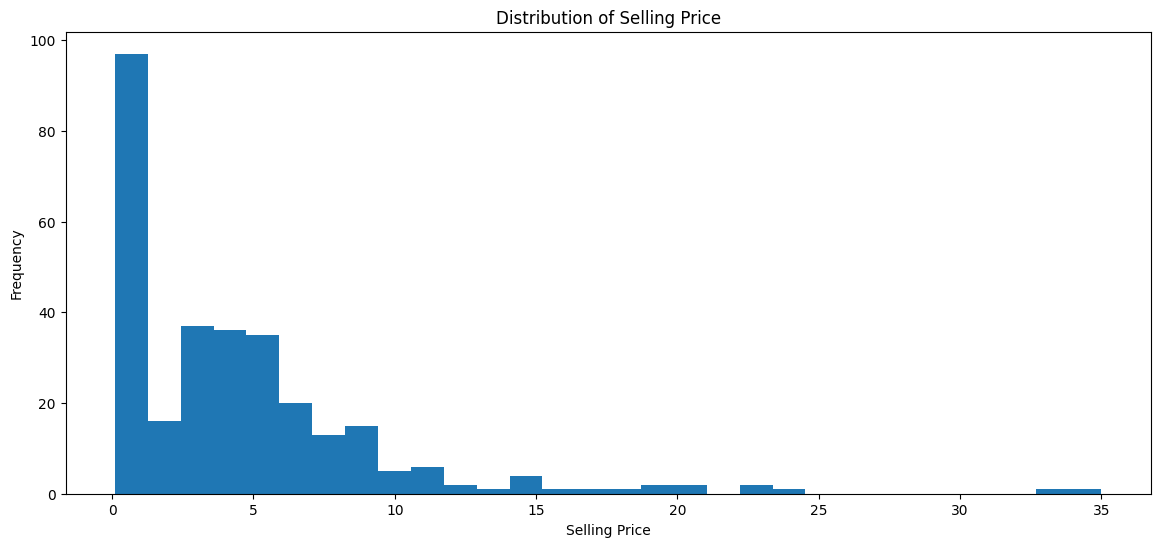

In [17]:
#Exploratory Data Analysis (EDA)
#Distribution of the target variable 'selling_price'
plt.figure(figsize=(14, 6))
plt.hist(df['selling_price'], bins=30)
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.title('Distribution of Selling Price')
plt.show()

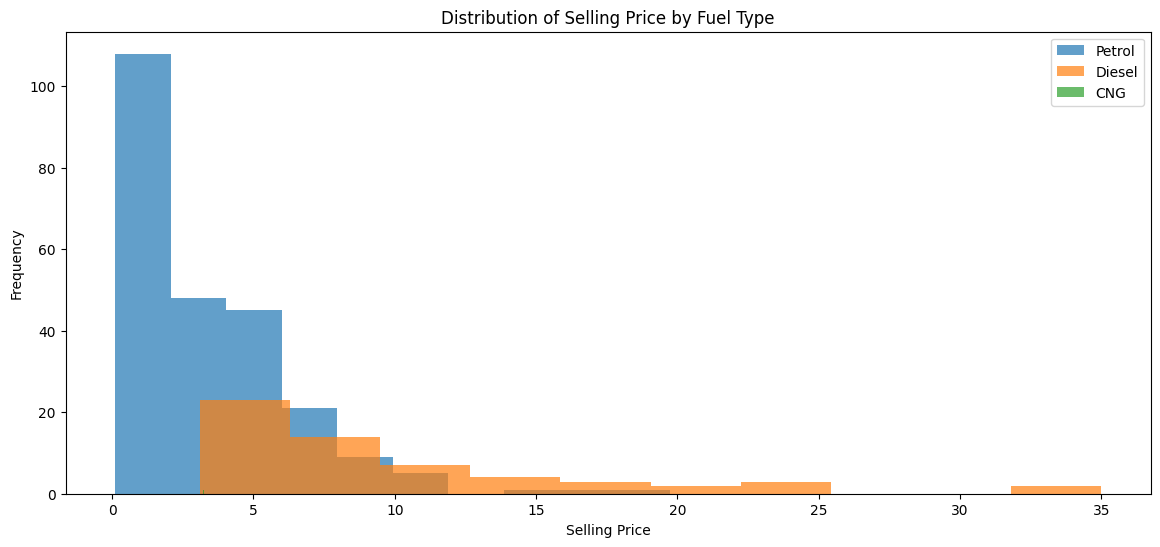

In [18]:
#Distribution of the target variable 'selling_price' by fuel type
plt.figure(figsize=(14, 6))
for fuel_type in df['fuel_type'].unique():
    plt.hist(df[df['fuel_type'] == fuel_type]['selling_price'], label=fuel_type, alpha=0.7)
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.title('Distribution of Selling Price by Fuel Type')
plt.legend()
plt.show()

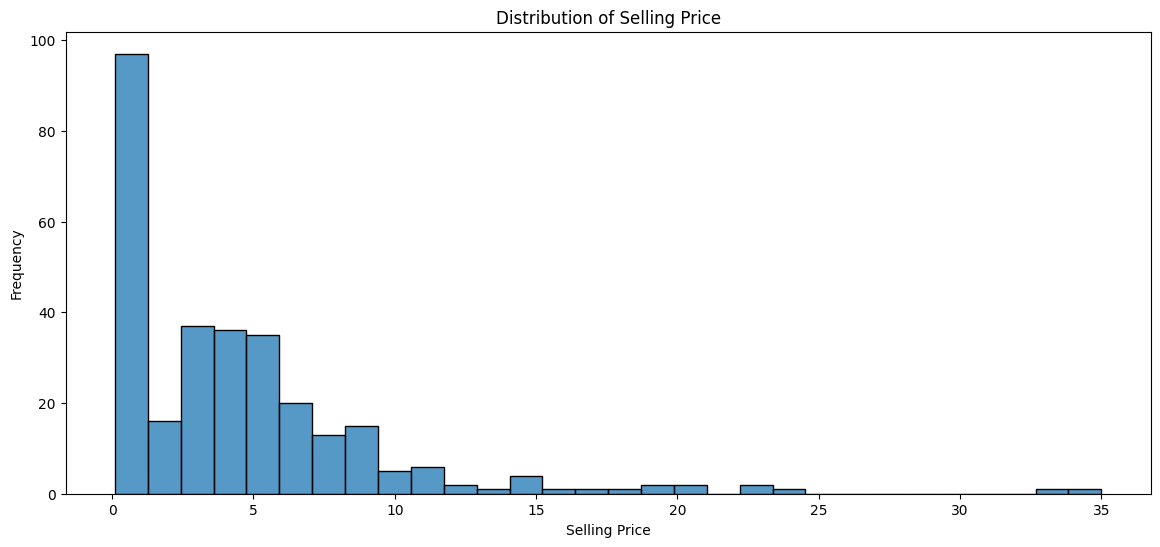

In [19]:
#Distribution of the target variable 'selling_price' using seaborn
plt.figure(figsize=(14, 6))
sns.histplot(data=df, x='selling_price', bins=30)
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.title('Distribution of Selling Price')
plt.show()

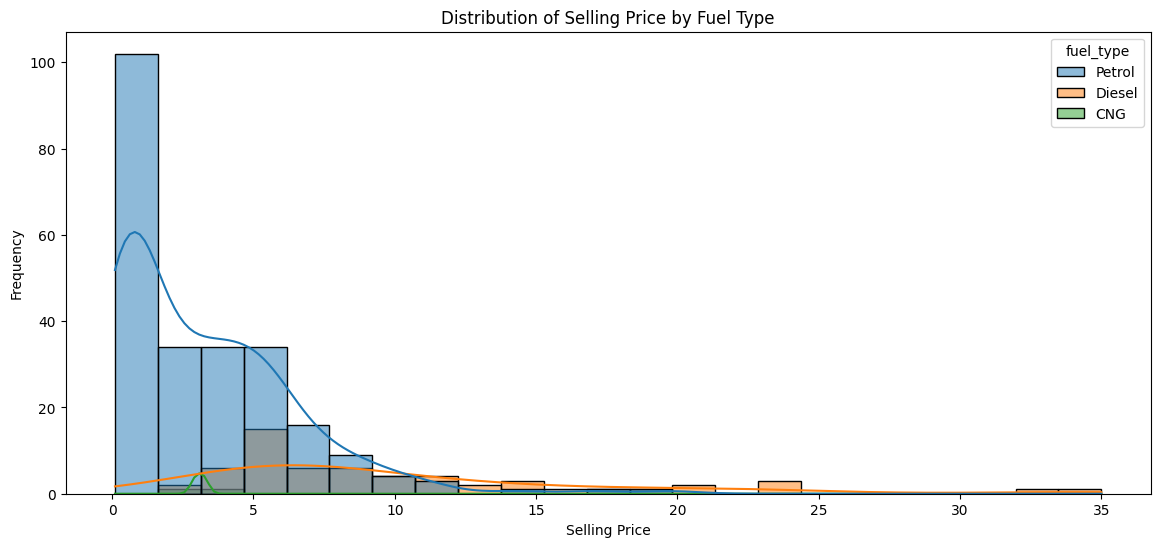

In [20]:
#Distribution of the target variable selling_price by fuel type using seaborn and kde
plt.figure(figsize=(14, 6))
sns.histplot(data=df, x='selling_price', hue='fuel_type', kde=True)
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.title('Distribution of Selling Price by Fuel Type')
plt.show()

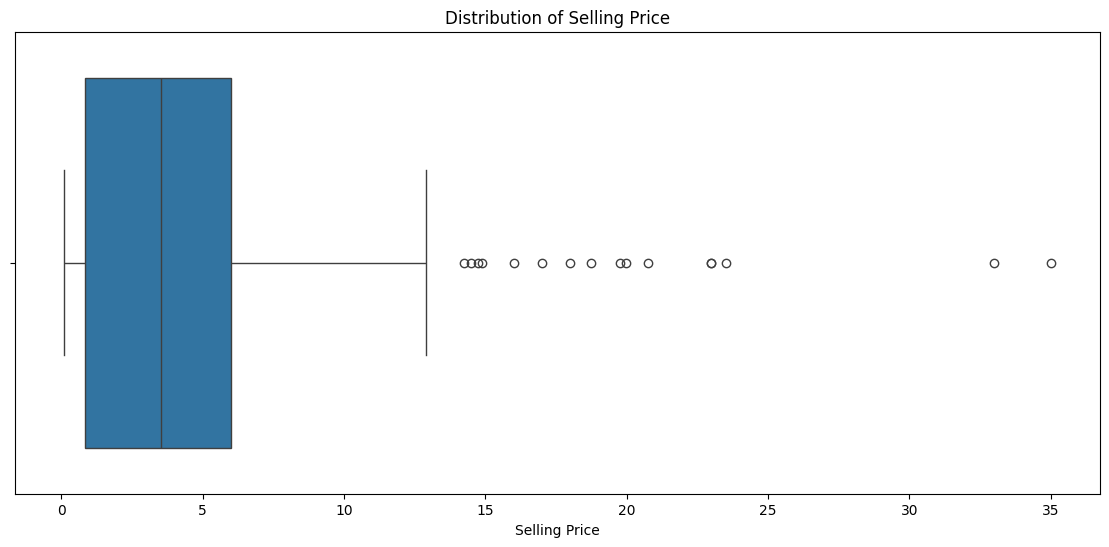

In [21]:
#Distribution of the target variable 'selling_price' using boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='selling_price')
plt.xlabel('Selling Price')
plt.title('Distribution of Selling Price')
plt.show()

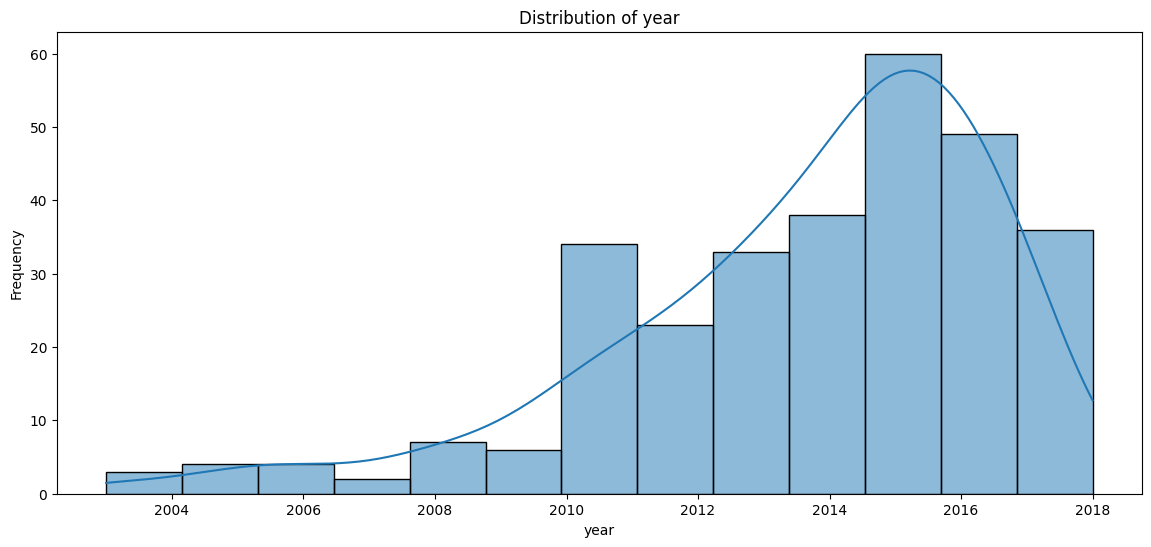

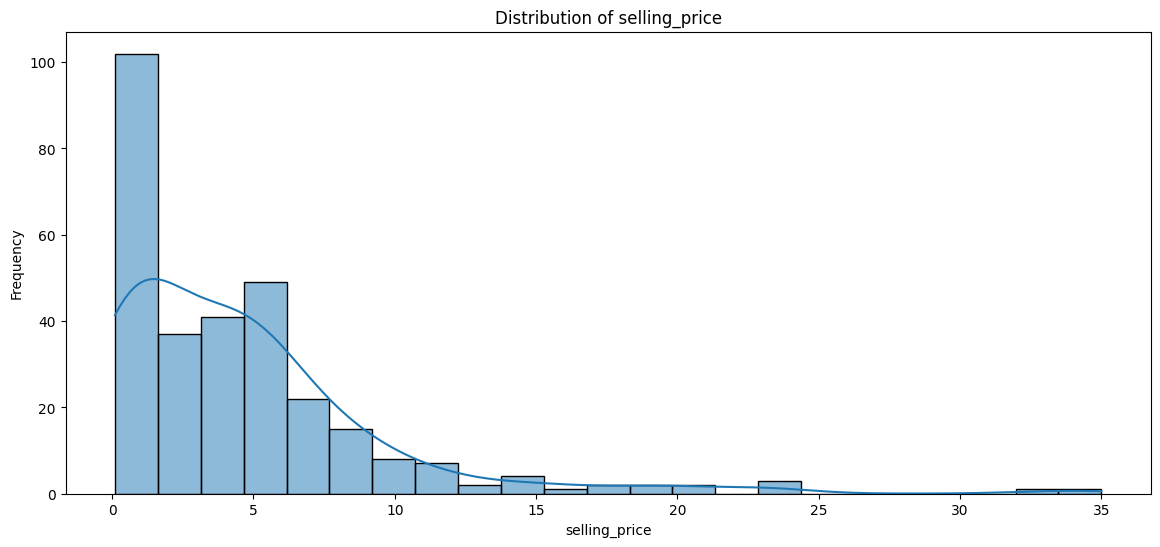

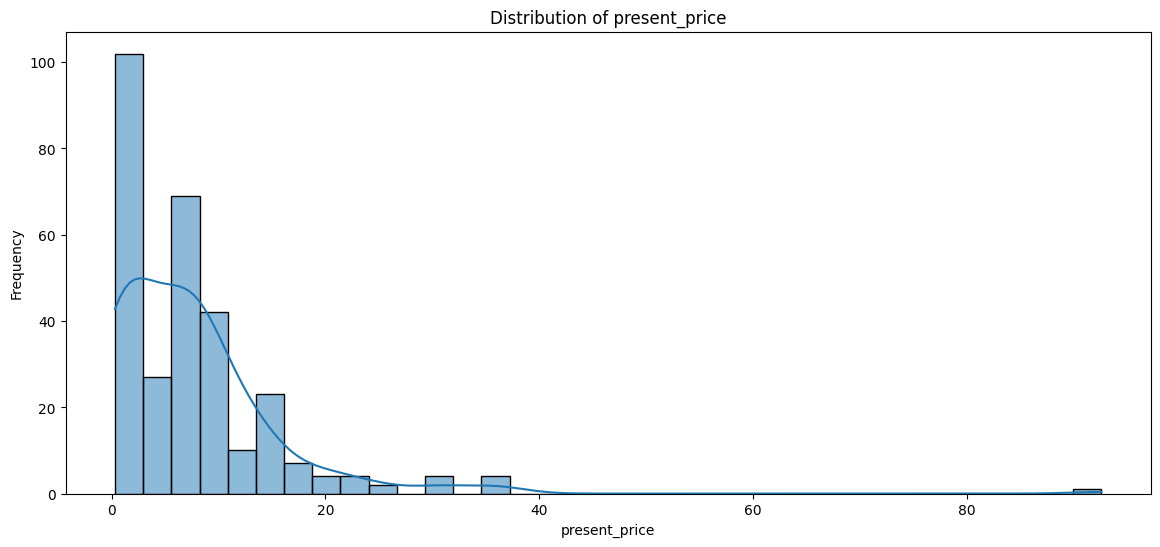

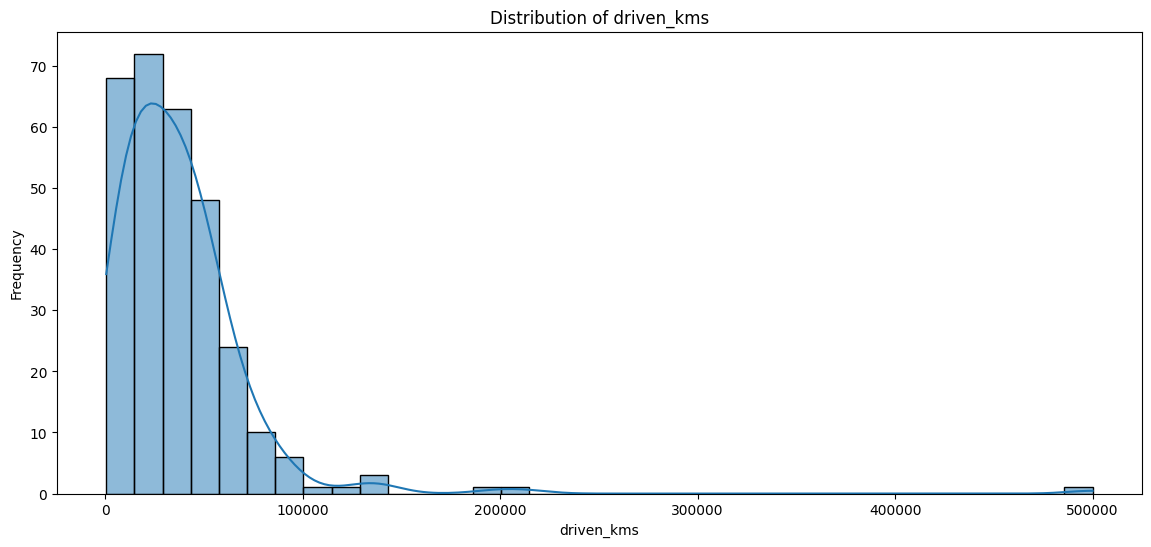

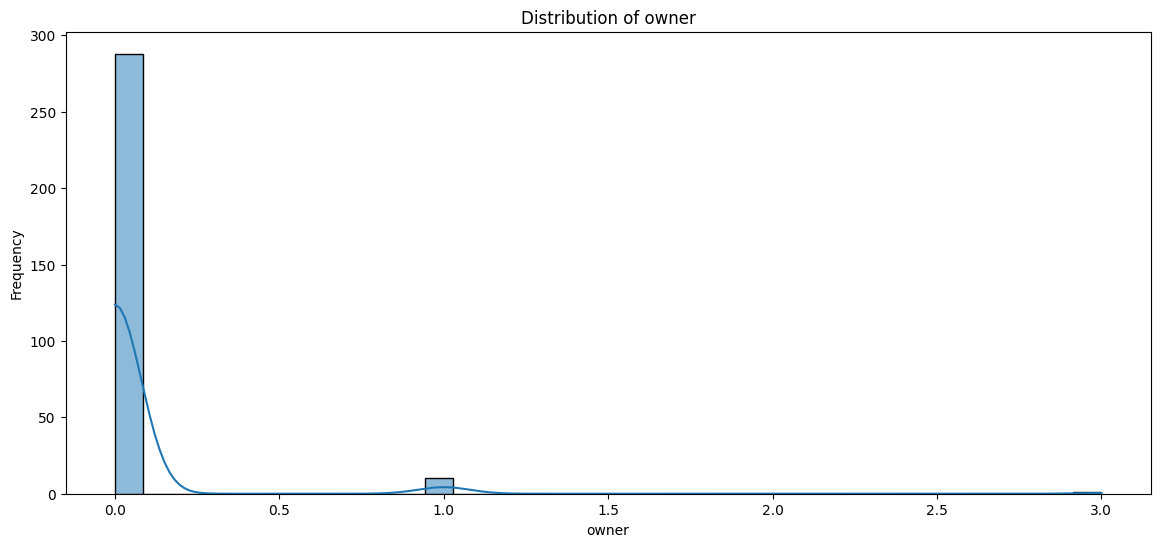

In [22]:
#distribution of Numerical features in the dataset using histograms,sns and kde
for column in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(14, 6))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

C:\Users\Sirlaw\AppData\Local\Temp\ipykernel_27892\3109265335.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


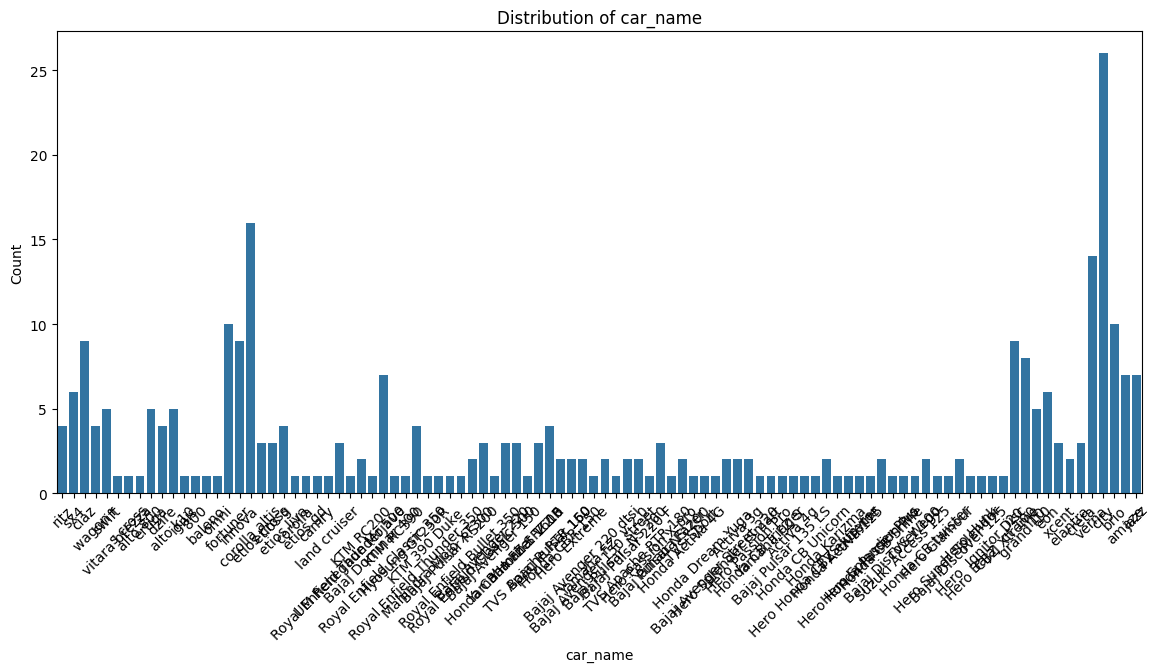

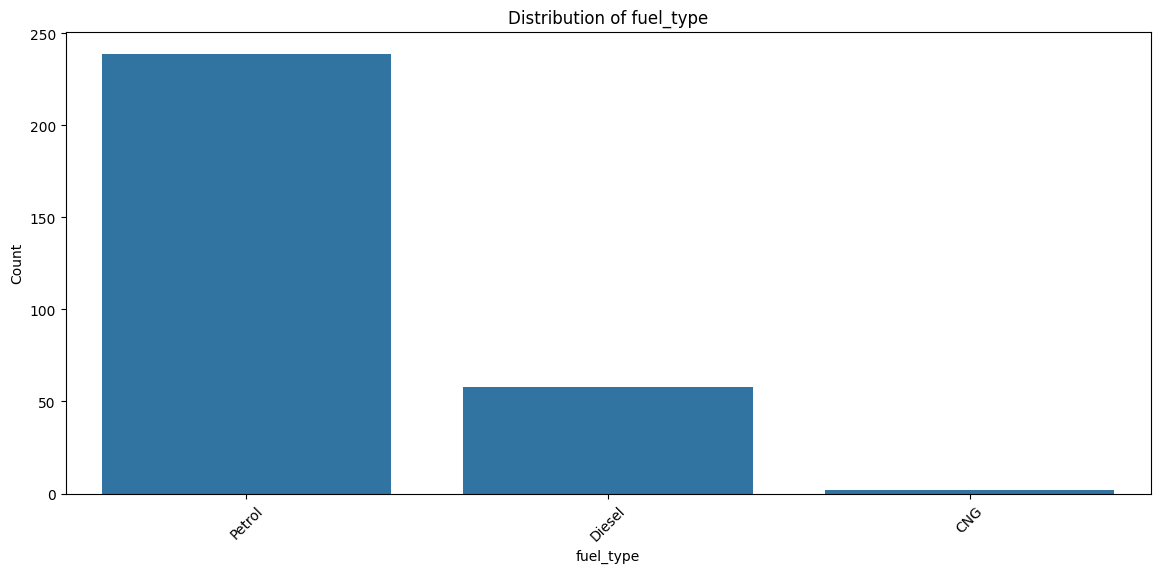

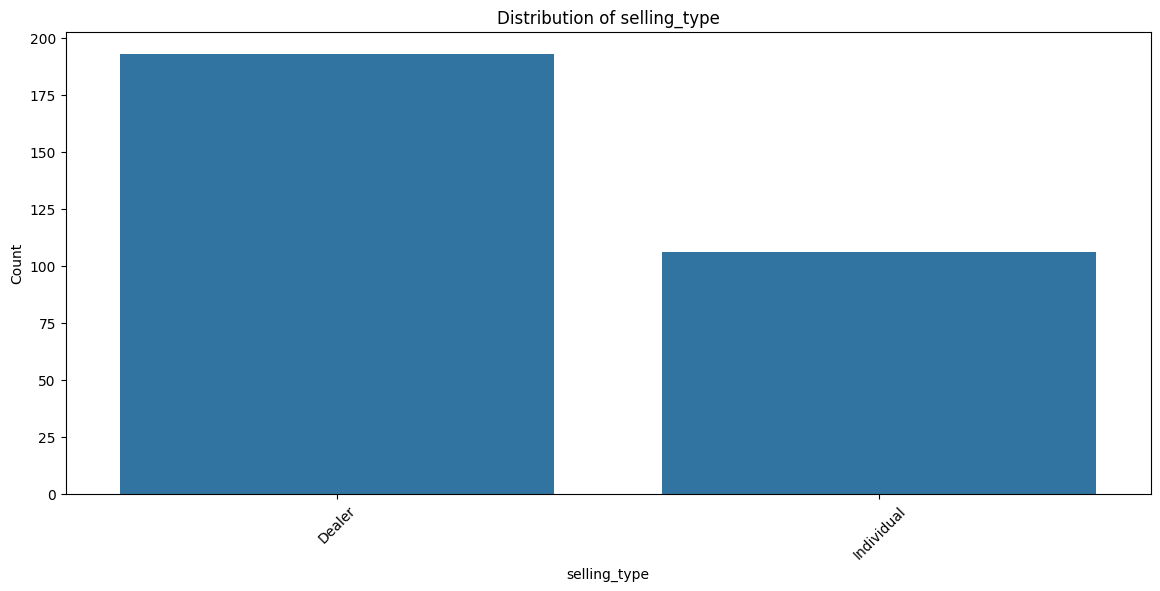

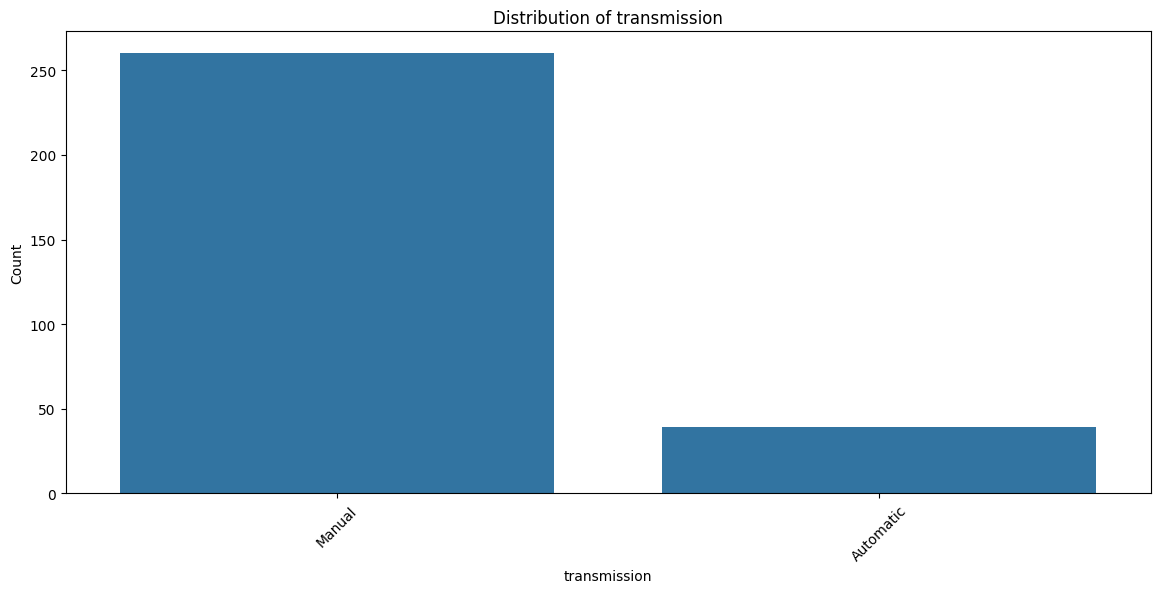

In [23]:
#Distribution of categorical variables using countplot
categorical_columns = df.select_dtypes(include=['object']).columns
for column in categorical_columns:
    plt.figure(figsize=(14, 6))
    sns.countplot(data=df, x=column)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

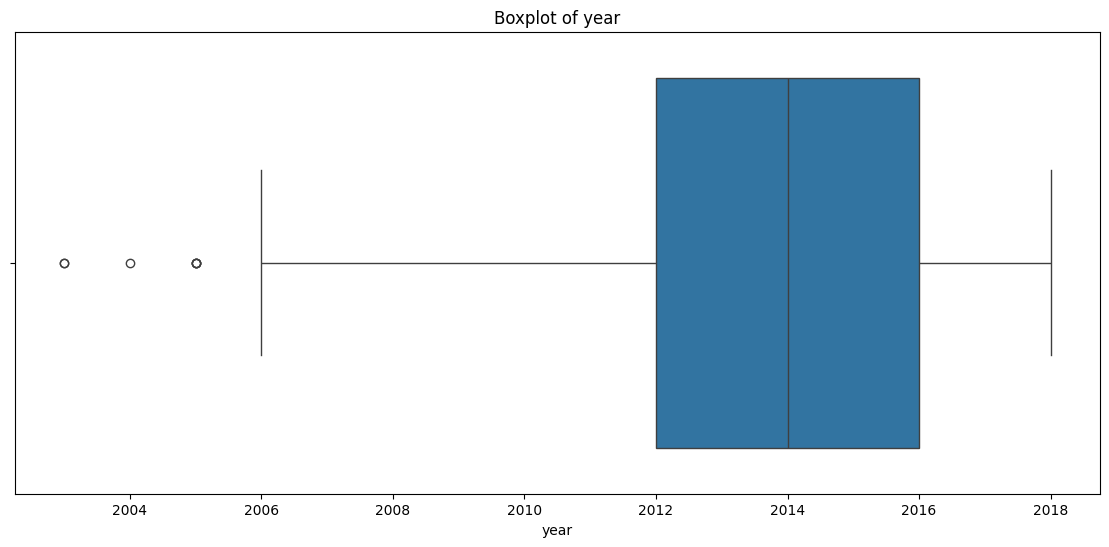

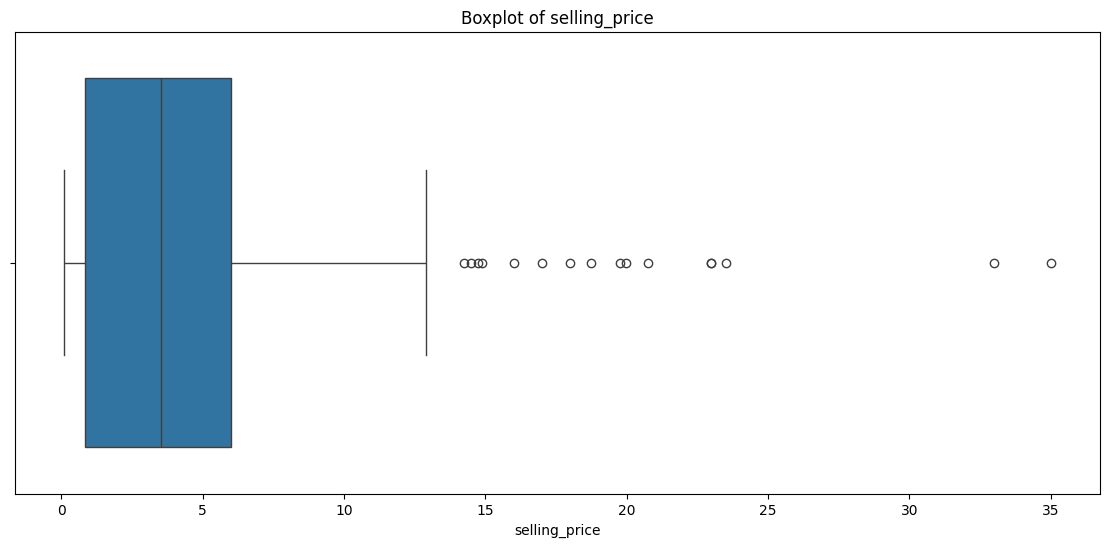

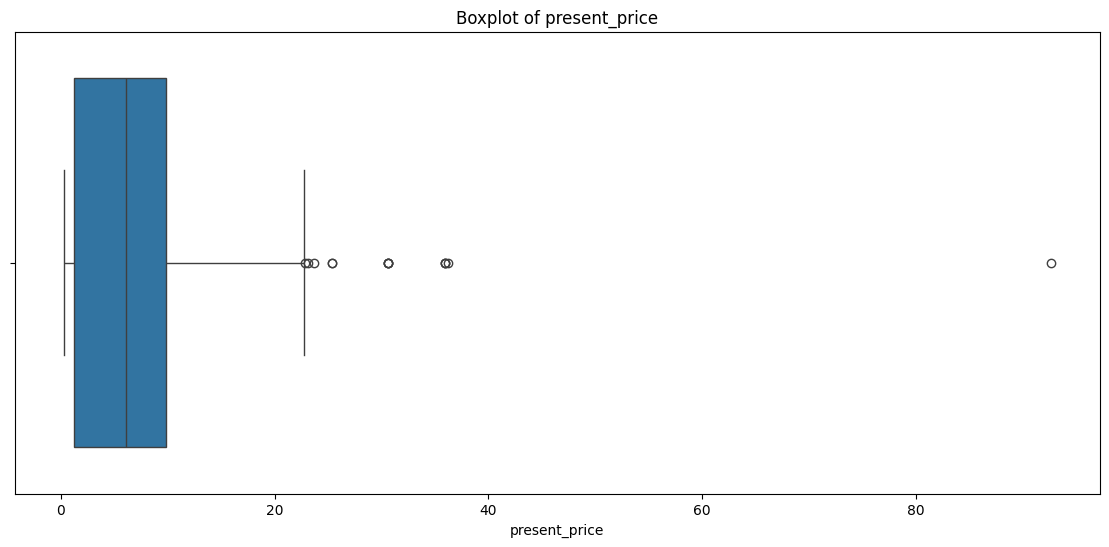

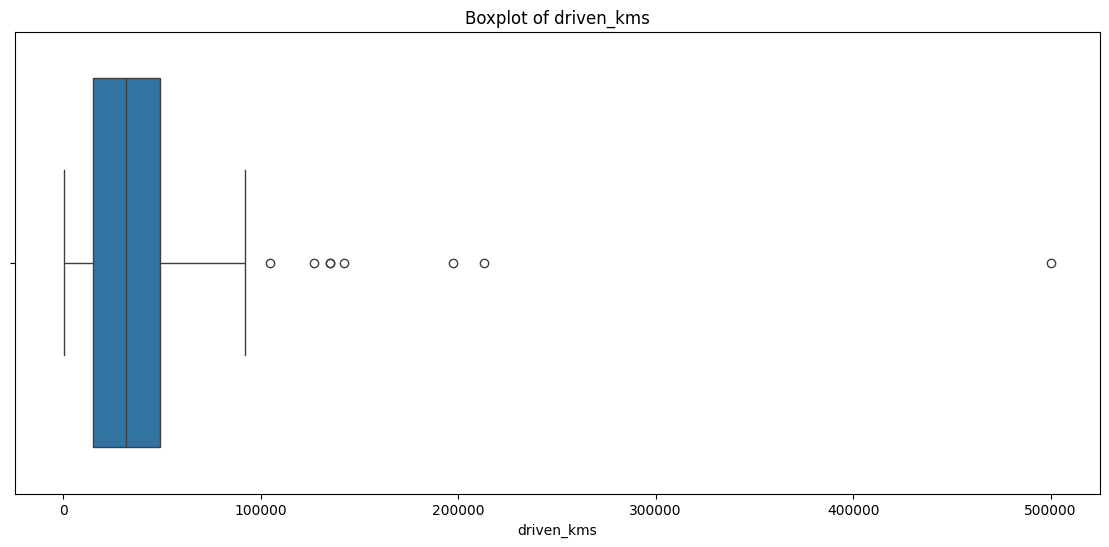

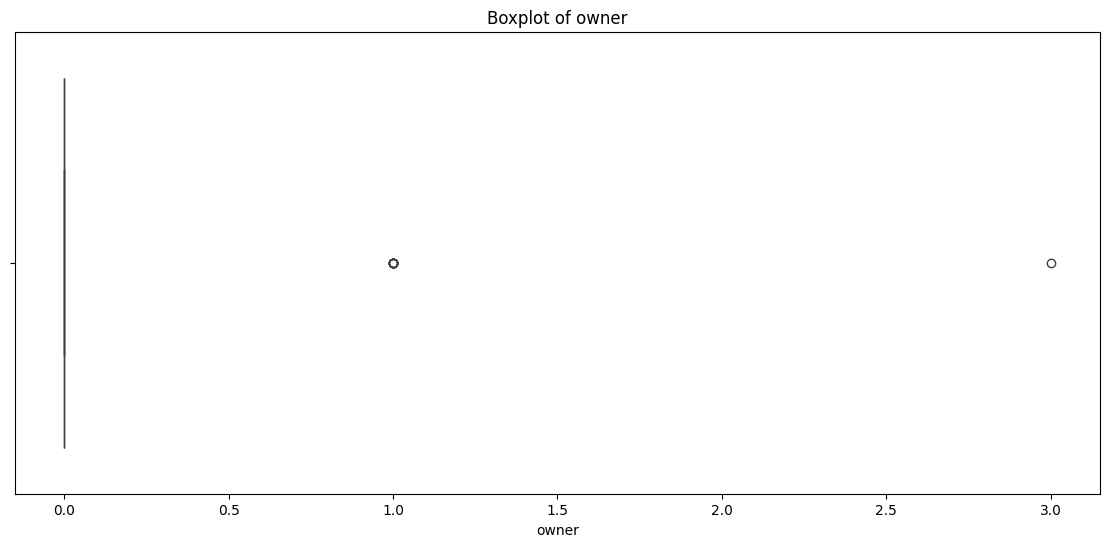

In [24]:
#Plotting boxplots for numerical features to visualize outliers
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
for column in numerical_columns:
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df, x=column)
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

In [25]:
#Handling outliers in the dataset using IQR method
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

<Axes: >

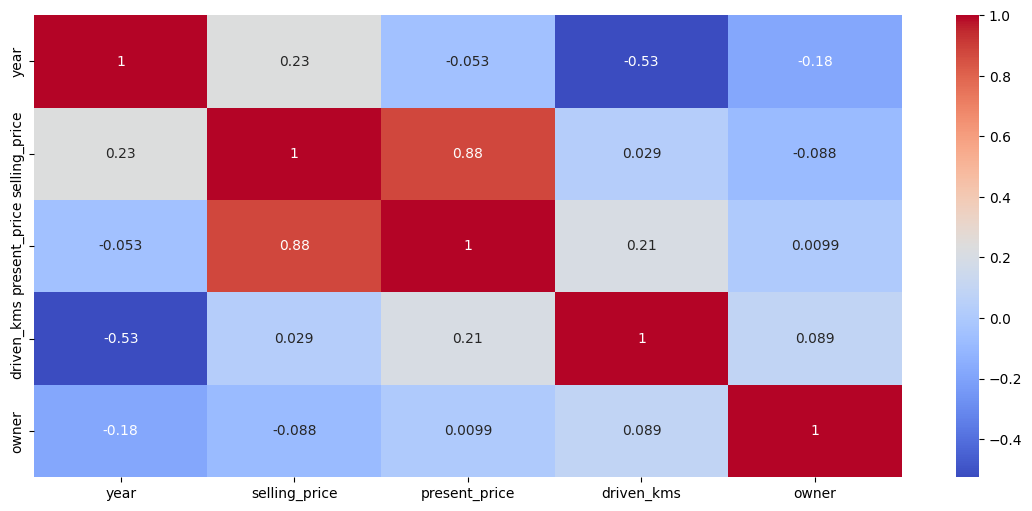

In [26]:
#Plotting the correlation heatmap of the numerical features in the dataset
plt.figure(figsize=(14, 6))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm')

In [27]:
#Feature Engineering
#Creating a new feature 'car_age' by subtracting the 'year' from the current year
from datetime import datetime

df['car_age'] = datetime.now().year - df['year']

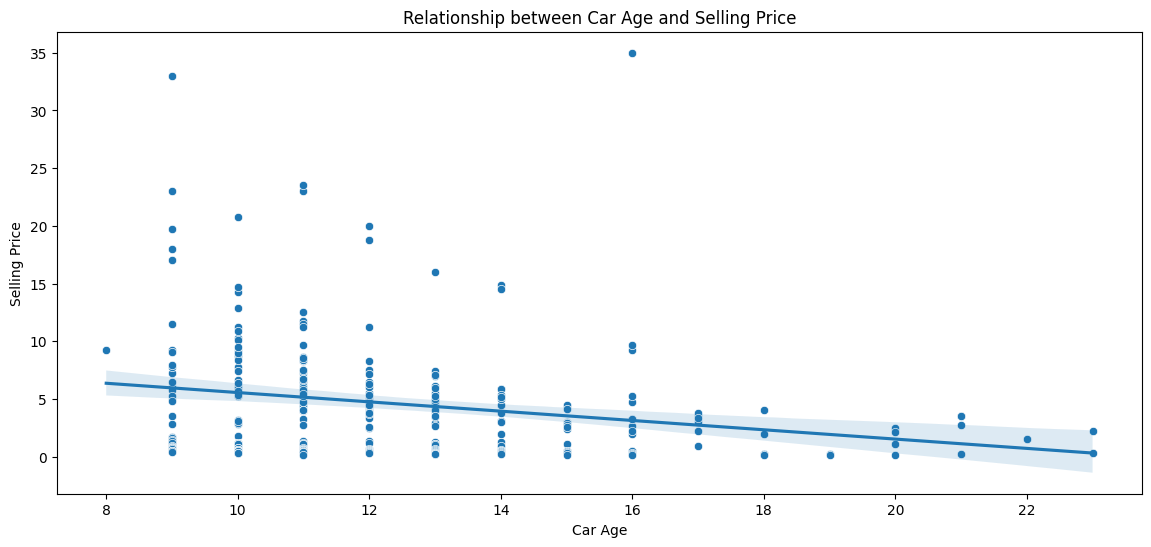

In [28]:
#Visualizing the relationship between 'car_age' and 'selling_price' using scatter plot and regression line
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df, x='car_age', y='selling_price')
sns.regplot(data=df, x='car_age', y='selling_price', scatter=False)
plt.title('Relationship between Car Age and Selling Price')
plt.xlabel('Car Age')
plt.ylabel('Selling Price')
plt.show()

The scatter plot reveals a negative relationship between Car Age and Selling Price, indicating that the selling price generally decreases as a car becomes older. However, the wide spread of data points around the regression line suggests that this relationship is weak to moderate, implying that car age alone is insufficient to accurately predict selling price. The presence of several high-priced outliers further indicates that other factors, such as the car's current market price, mileage, fuel type, transmission, and brand, also play significant roles in determining its selling price.

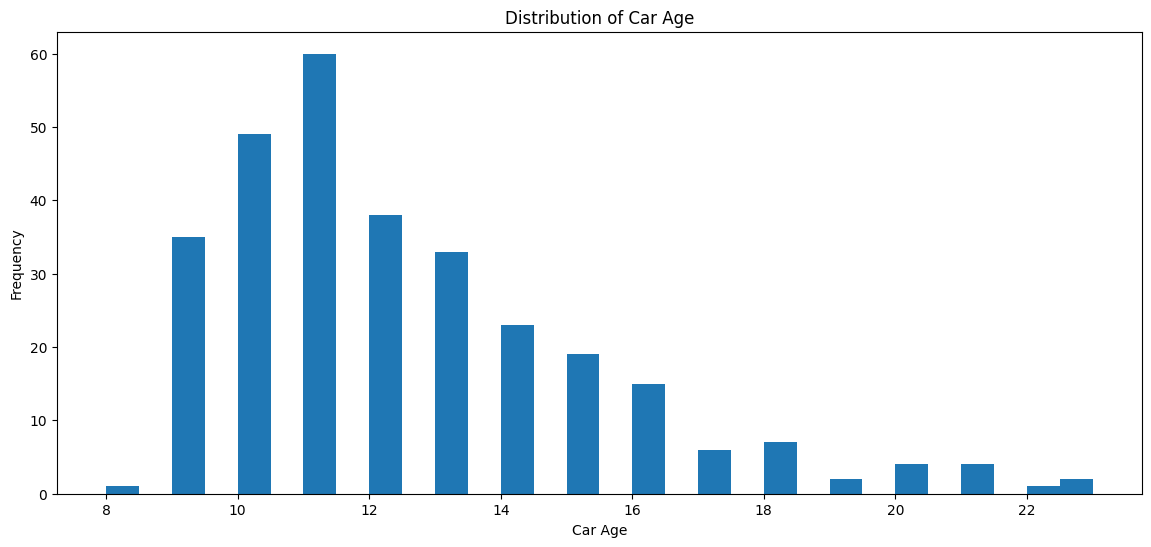

In [29]:
#Distribution of 'car_age' using histogram
plt.figure(figsize=(14, 6))
plt.hist(df['car_age'], bins=30)
plt.xlabel('Car Age')
plt.ylabel('Frequency')
plt.title('Distribution of Car Age')
plt.show()

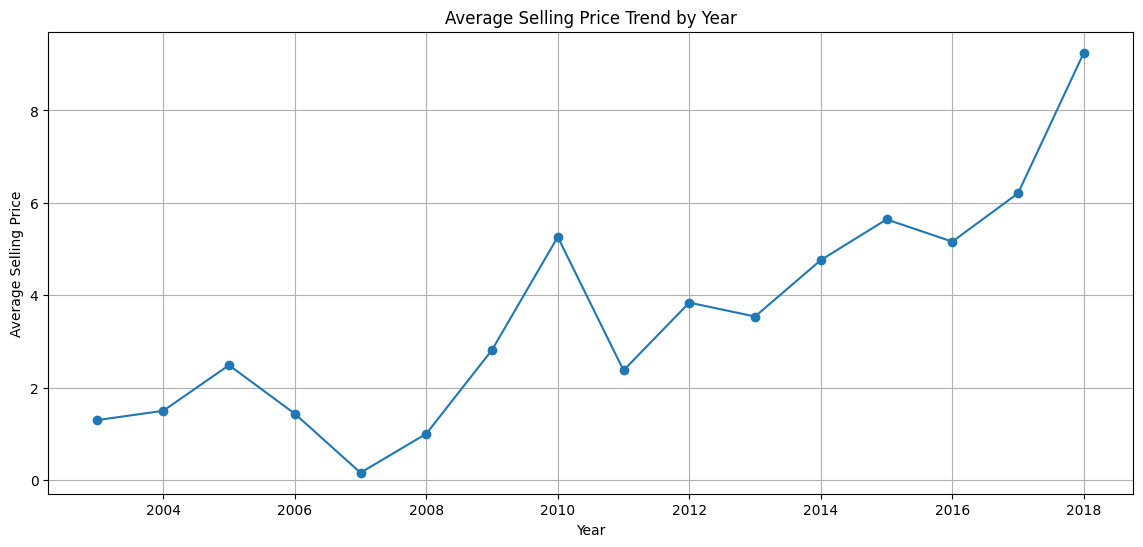

In [30]:
#yearly trend of average selling price by year
yearly_trend = df.groupby('year')['selling_price'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(
    yearly_trend['year'],
    yearly_trend['selling_price'],
    marker='o'
)

plt.title('Average Selling Price Trend by Year')
plt.xlabel('Year')
plt.ylabel('Average Selling Price')
plt.grid(True)
plt.show()

Insight:

The chart shows an overall upward trend in average selling prices from 2003 to 2018, despite some fluctuations. Prices were lowest around 2007 and highest in 2018, with particularly strong growth after 2011. This suggests that newer vehicles generally have higher selling prices.


In [31]:
#Importing the required machine learning libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
#Defining the features and target variable
X = df.drop(['selling_price'], axis=1)
y = df['selling_price']

In [33]:
#Dropping Car name column as it is not useful for model training
X = df.drop(["selling_price", "car_name","year"], axis=1)
y = df["selling_price"]

In [34]:
X.head()

,present_price,driven_kms,fuel_type,selling_type,transmission,owner,car_age
0,5.59,27000,Petrol,Dealer,Manual,0,12
1,9.54,43000,Diesel,Dealer,Manual,0,13
2,9.85,6900,Petrol,Dealer,Manual,0,9
3,4.15,5200,Petrol,Dealer,Manual,0,15
4,6.87,42450,Diesel,Dealer,Manual,0,12


In [35]:
#Identify categorical and numerical features
numeric_features = [
    "present_price",
    "driven_kms",
    "owner",
    "car_age"
]

categorical_features = [
    "fuel_type",
    "selling_type",
    "transmission"
]

In [36]:
#Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [37]:
#Checking the shape of the training and testing sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (239, 7)
X_test shape: (60, 7)
y_train shape: (239,)
y_test shape: (60,)


In [38]:
#Building a preprocessing pipeline for numerical and categorical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [39]:
#Simple basline model using Linear Regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

#Training the linear regression model
linear_model.fit(X_train, y_train)

#Making predictions using the linear regression model
y_pred_linear = linear_model.predict(X_test)


In [40]:
#Evaluating the linear regression model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.4725457508178637
MSE: 6.373125106260703
RMSE: 2.5245049230018752
R²: 0.7527233824220487


In [41]:
#Create a Model Evaluation Function to evaluate different models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [42]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor

dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=42,
            max_depth=5
        ))
    ]
)


In [43]:
#EValuating Decison Tree Model
dt_results = evaluate_model(
    dt_model,
    X_train,
    X_test,
    y_train,
    y_test
)

dt_results

{'MAE': 1.451139178984625,
 'MSE': 9.674881501800177,
 'RMSE': np.float64(3.110447154638731),
 'R2': 0.6246155640531099}

In [44]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            max_depth=None,
            min_samples_split=2
        ))
    ]
)

In [45]:
#EValuation of Randomforest 
rf_results = evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_results

{'MAE': 1.5319561111111093,
 'MSE': 13.651046861944431,
 'RMSE': np.float64(3.6947323126235316),
 'R2': 0.47034074521717983}

In [46]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

In [47]:
#Evaluation
gb_results = evaluate_model(
    gb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

gb_results

{'MAE': 1.1254410726436714,
 'MSE': 6.32409623008248,
 'RMSE': np.float64(2.5147755824491536),
 'R2': 0.7546256979207809}

In [48]:
#Comparing Models
results = pd.DataFrame({
    "Linear Regression": evaluate_model(
        linear_model, X_train, X_test, y_train, y_test
    ),
    
    "Decision Tree": evaluate_model(
        dt_model, X_train, X_test, y_train, y_test
    ),
    
    "Random Forest": evaluate_model(
        rf_model, X_train, X_test, y_train, y_test
    ),
    
    "Gradient Boosting": evaluate_model(
        gb_model, X_train, X_test, y_train, y_test
    ),
    
}).T

results

,MAE,MSE,RMSE,R2
Linear Regression,1.472546,6.373125,2.524505,0.752723
Decision Tree,1.451139,9.674882,3.110447,0.624616
Random Forest,1.531956,13.651047,3.694732,0.470341
Gradient Boosting,1.125441,6.324096,2.514776,0.754626


In [49]:
#Cross Validation using k-Fold
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [50]:
#Random Forest
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

print("CV RMSE scores:", -cv_scores)
print("Mean CV RMSE:", -cv_scores.mean())
print("Std CV RMSE:", cv_scores.std())

CV RMSE scores: [3.43817761 0.86980732 2.32323757 0.96094809 0.74546143]
Mean CV RMSE: 1.667526405503983
Std CV RMSE: 1.0536579437001168


In [51]:
#Compare Model Using Cross validationm
models = {
    "Linear Regression": linear_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )

    cv_results.append({
        "Model": name,
        "Mean RMSE": -scores.mean(),
        "Std RMSE": scores.std()
    })

cv_results = pd.DataFrame(cv_results)

cv_results.sort_values("Mean RMSE")

,Model,Mean RMSE,Std RMSE
3,Gradient Boosting,1.431199,0.816700
2,Random Forest,1.667526,1.053658
0,Linear Regression,1.870783,0.478291
1,Decision Tree,1.894262,0.813182


In [52]:
#Hyperparameter Tunning
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [100, 150, 200, 300, 400, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1, 0.15],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.7, 0.8, 0.9, 1.0]
}
gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)
gb_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dire

In [53]:
#Finding the Best Parameter
print("Best Parameters:")
print(gb_search.best_params_)
print("Best CV RMSE:")
print(-gb_search.best_score_)
-gb_search.best_score_

Best Parameters:
{'model__subsample': 0.7, 'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 4, 'model__learning_rate': 0.08}
Best CV RMSE:
1.2165443040521517


np.float64(1.2165443040521517)

In [54]:
#Get the Tunned Model
best_gb_model = gb_search.best_estimator_

In [55]:
#Evaluating on the test Set
y_pred_tuned = best_gb_model.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred_tuned)
mse = mean_squared_error(y_test, y_pred_tuned)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tuned)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.1905712675961218
MSE: 6.830586301610081
RMSE: 2.6135390377054026
R²: 0.7349739337335182


In [56]:
#Actual Vs Predicted Price
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_tuned
})

comparison.head(10)


,Actual,Predicted
0,8.99,9.339568
1,8.35,9.088203
2,0.45,0.548966
3,7.45,7.148918
4,5.25,12.670598
5,5.25,4.771162
6,5.85,5.324191
7,1.15,1.282730
8,9.25,8.130256
9,0.38,0.439391


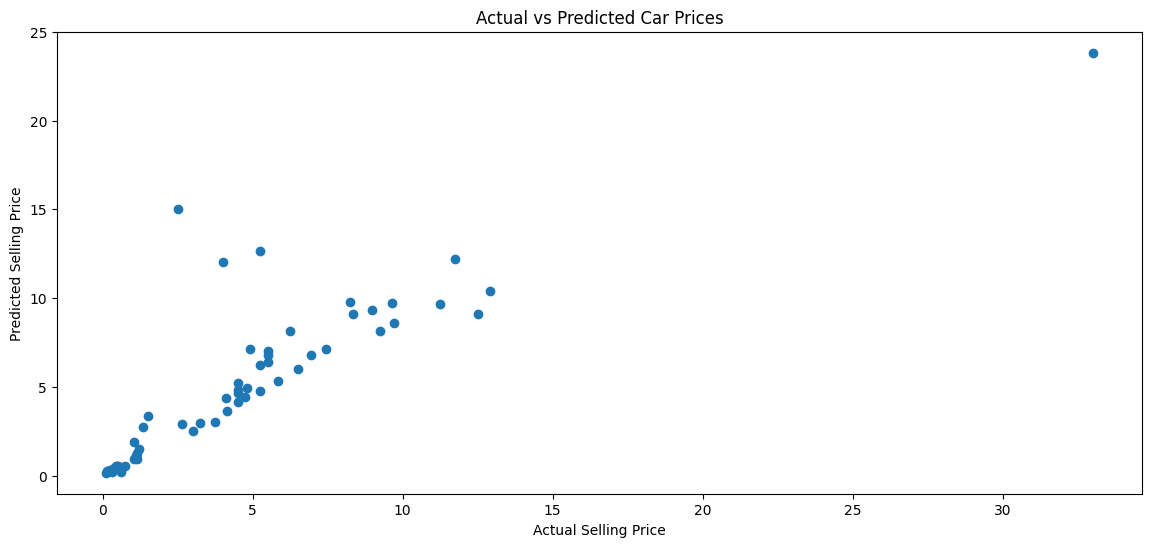

In [57]:
#Plot of Actual Vs predicted Price
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.scatter(
    comparison["Actual"],
    comparison["Predicted"],
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

The **Actual vs Predicted Car Prices** plot shows a strong positive relationship between actual and predicted prices, indicating that the model generally captures the underlying pricing pattern well. Most predictions are reasonably close to the expected trend, particularly for lower- and mid-priced cars. However, the model shows larger errors for some higher-priced vehicles, including a noticeable extreme case, suggesting that it may struggle with expensive cars and potential outliers.


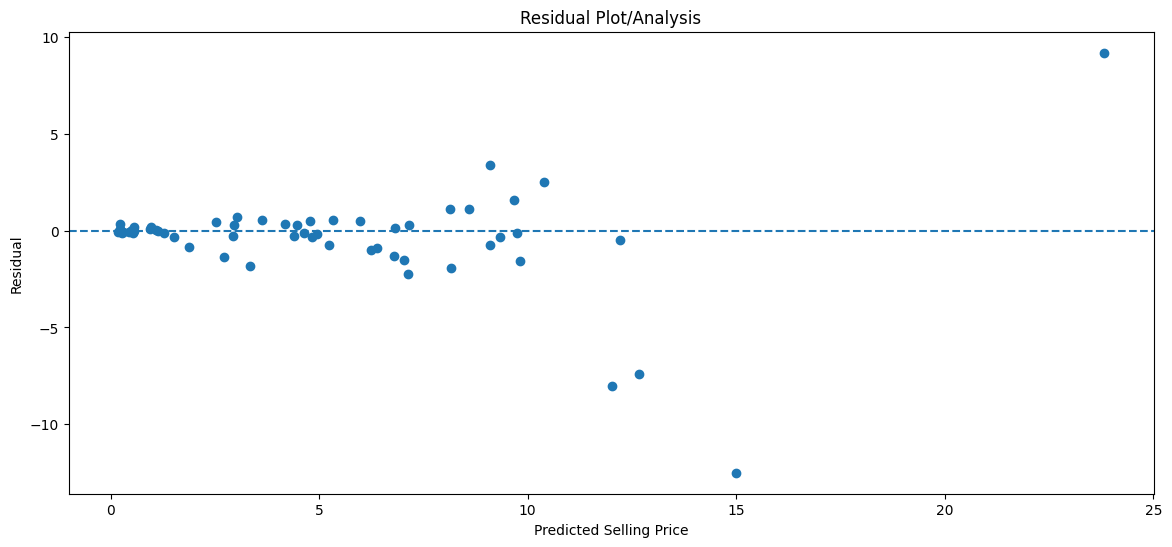

In [58]:
#Residual Analysis
residuals = y_test - y_pred_tuned
#Plot
plt.figure(figsize=(14, 6))

plt.scatter(
    y_pred_tuned,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residual Plot/Analysis")

plt.show()

The residual plot shows that **most residuals are clustered around zero**, indicating that the model generally makes reasonably accurate predictions without a strong systematic bias. However, there are several **large positive and negative residuals**, particularly at higher predicted selling prices, suggesting the presence of **outliers and increasing prediction errors for expensive cars**. Overall, the model performs well for lower-priced cars but has more difficulty accurately predicting some higher-priced vehicles.


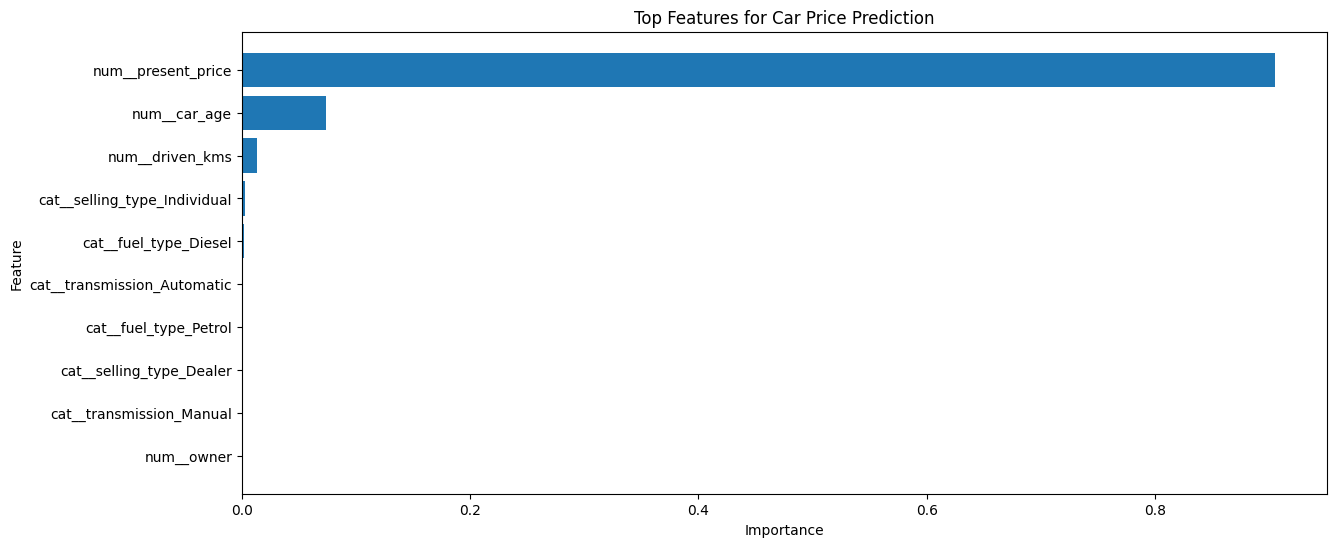

In [59]:
#Feauture Importance
best_model = gb_search.best_estimator_

preprocessor_fitted = best_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

feature_names

model = best_model.named_steps["model"]

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)
plt.figure(figsize=(14, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features for Car Price Prediction")

plt.gca().invert_yaxis()

plt.show()

Key Insight: The model's predictions are driven primarily by Present Price and Car Age, which together account for roughly 97% of the total feature importance. This indicates that the car's current market value and age are substantially more influential than its fuel type, transmission, selling type, or number of previous owners.

In [60]:
#Prediction Function
new_car = pd.DataFrame({
    "present_price": [8.5],
    "driven_kms": [25000],
    "fuel_type": ["Petrol"],
    "selling_type": ["Dealer"],
    "transmission": ["Manual"],
    "owner": [0],
    "car_age": [5]
})
predicted_price = best_model.predict(new_car)

print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 6.77262518688178


In [61]:
#Saving the Trained Model
import joblib

joblib.dump(
    best_model,
    "car_price_prediction_model.pkl"
)

['car_price_prediction_model.pkl']

In [62]:
model = joblib.load(
    "car_price_prediction_model.pkl"
)